In [74]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import pandas as pd

In [24]:
params_to_load = [165, 166]

datasets = []
wetterdaten = []
for name in ['ecmwf_sfc_2019-01-01_00.grb', 'ecmwf_sfc_2019-01-07_00.grb', 'ecmwf_sfc_2019-01-14_00.grb', 'ecmwf_sfc_2019-01-21_00.grb', 'ecmwf_sfc_2019-01-28_00.grb']:
    for pid in params_to_load:
        ds = xr.open_dataset(
            name,
            engine="cfgrib",
            backend_kwargs={
                "filter_by_keys": {
                    "paramId": pid,
                }
            }
        )
        datasets.append(ds)
    # Zusammenführen zu einem Dataset mit mehreren Variablen
    combined = xr.merge(datasets)
    datasets = []
    wetterdaten.append(combined)

In [25]:
windspeed_mean = []
for ds in wetterdaten:
    windspeed = np.sqrt(ds["u10"]**2 + ds["v10"]**2)
    ds["windspeed"] = windspeed * (100 / 10) ** 0.143

    windspeed_mean.append(ds["windspeed"].mean(dim=["latitude", "longitude"]))

In [26]:
import numpy as np

def hourly_cf_from_wind(wind_100m: np.ndarray) -> np.ndarray:
    """
    Berechnet den stündlichen Capacity Factor (Leistungsanteil) aus Windgeschwindigkeiten
    gemäß vereinfachter Power Curve der Vestas V112-3.0MW.

    Parameters:
        wind_100m (np.ndarray): 1D-Array stündlicher Windgeschwindigkeit [m/s]

    Returns:
        np.ndarray: 1D-Array stündlicher Capacity Factors (0.0 – 1.0)
    """
    def power_curve(v):
        return np.piecewise(
            v,
            [
                v < 3.5,
                (v >= 3.5) & (v < 4.0),
                (v >= 4.0) & (v < 6.0),
                (v >= 6.0) & (v < 10.0),
                (v >= 10.0) & (v < 12.5),
                (v >= 12.5) & (v < 25.0),
                v >= 25.0
            ],
            [
                0,
                lambda v: (v - 3.5) / 0.5 * 50,
                lambda v: 50 + (v - 4.0) / 2.0 * 400,
                lambda v: 450 + (v - 6.0) / 4.0 * 1500,
                lambda v: 1950 + (v - 10.0) / 2.5 * 1050,
                3000,
                0
            ]
        )

    power_output = power_curve(wind_100m)        # in Watt
    cf_hourly = power_output / 3_000         # normiert auf 3 MW
    return cf_hourly

In [46]:
n = pypsa.Network('base_s_1__none_2045_lt.nc')

INFO:pypsa.io:Imported network base_s_1__none_2045_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


In [60]:
n.generators_t.p_max_pu['DE0 0 onwind-2020'].loc['2019-01-01 00:00:00': '2019-07-01 00:00:00']

snapshot
2019-01-01 00:00:00    0.457638
2019-01-01 03:00:00    0.597322
2019-01-01 06:00:00    0.691964
2019-01-01 09:00:00    0.693188
2019-01-01 12:00:00    0.752251
                         ...   
2019-06-30 12:00:00    0.291736
2019-06-30 15:00:00    0.267502
2019-06-30 18:00:00    0.235904
2019-06-30 21:00:00    0.171728
2019-07-01 00:00:00    0.108359
Name: DE0 0 onwind-2020, Length: 1449, dtype: float64

# Capacity Faktor aus den Pertubated Forecasts + aus Pypsa-Netzwerk

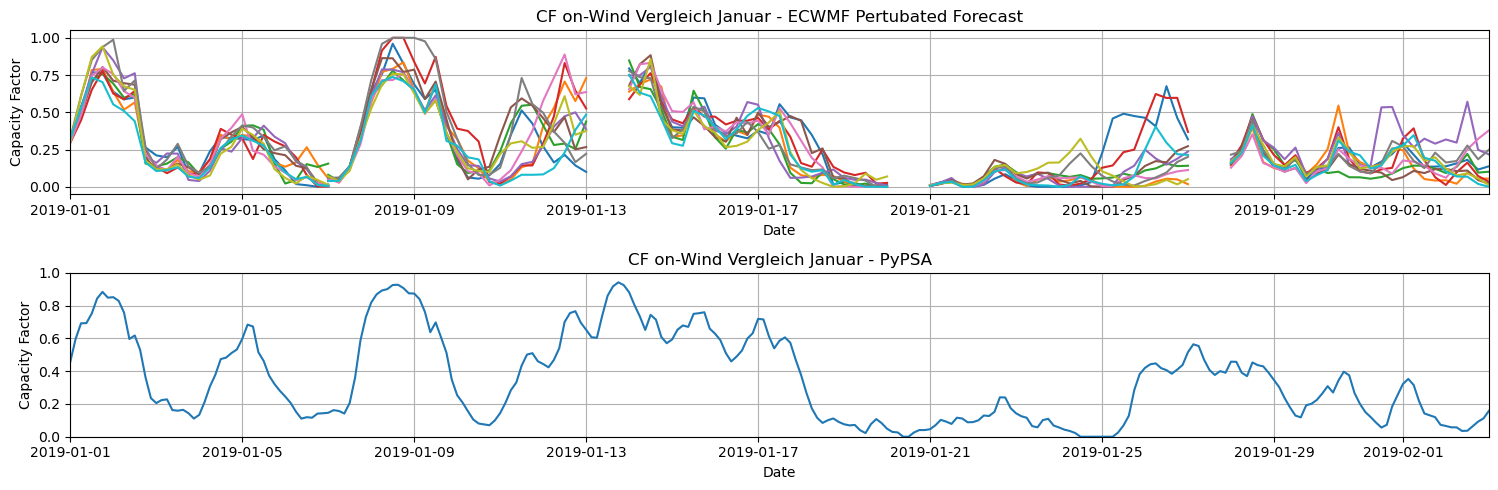

In [94]:
fig, ax = plt.subplots(2,1, figsize=(15,5))
for i, w in enumerate(windspeed_mean):
    for number in range(1,11):
        ax[0].plot(
            w["valid_time"].values,
            hourly_cf_from_wind(w.sel(number=number).values),
            label=f"ECMWF Pertubated Forecast Nr {n}"
        )
        ax[0].set_xlabel('Date')
        ax[0].set_ylabel('Capacity Factor')
        ax[0].grid(True)
        ax[0].set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-02-03"))
        #ax[0].set_xlim(np.datetime64)

ax[1].plot(n.generators_t.p_max_pu['DE0 0 onwind-2020'].loc['2019-01-01 00:00:00': '2019-02-03 00:00:00'].index.values,
         n.generators_t.p_max_pu['DE0 0 onwind-2020'].loc['2019-01-01 00:00:00': '2019-02-03 00:00:00'].values,
         label='Pypsa-Network'
) 

ax[1].grid(True)

ax[1].set_xlabel('Date')
ax[1].set_ylabel('Capacity Factor')
ax[1].set_ylim(0, 1)
ax[1].set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-02-03"))

ax[0].set_title('CF on-Wind Vergleich Januar - ECWMF Pertubated Forecast')
ax[1].set_title('CF on-Wind Vergleich Januar - PyPSA')
plt.tight_layout()